Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


Import data

In [13]:
from pathlib import Path
import duckdb

# Resolve project root whether the notebook cwd is repo root or rec_system/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "rec_system":
    PROJECT_ROOT = PROJECT_ROOT.parent

DB_PATH = PROJECT_ROOT / "data" / "warehouse" / "api_sports.duckdb"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB not found at {DB_PATH}. "
        "Run `dbt run` (or copy the shared warehouse) first."
    )

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    df = con.execute("select * from main.bi_player_seasons").df()

print(f"Loaded {len(df):,} rows from {DB_PATH.name}")
df.head()


Data Cleaning

1. Drop duplicates

In [14]:
df = df.drop_duplicates()

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_season_id         11808 non-null  str    
 1   player_id                11808 non-null  int64  
 2   player_name              11808 non-null  str    
 3   nationality              11801 non-null  str    
 4   photo                    11808 non-null  str    
 5   height_cm                11772 non-null  float64
 6   weight_kg                11698 non-null  float64
 7   age                      11801 non-null  float64
 8   team_id                  11808 non-null  int64  
 9   team_name                11808 non-null  str    
 10  league_id                11808 non-null  int64  
 11  league_name              11808 non-null  str    
 12  season                   11808 non-null  int64  
 13  position                 11808 non-null  str    
 14  injured                  11808 no

2. Handle missing values

In [16]:
# Drop pass_accuracy_pct and passes completed
# Reason: data has been recorded since 2025, so all of the data before that was null
df = df.drop(columns=['pass_accuracy_pct', 'passes_completed'])


In [ ]:
# Position-conditional mean
# DuckDB returns height/weight as nullable Int32 — convert to float before fillna(mean).
conditional_mean_cols = [
    "shot_accuracy_pct",
    "goal_conversion_pct",
    "dribble_success_pct",
    "fouls_per_tackle",
    "duel_success_pct",
    "height_cm",
    "weight_kg",
]

for col in conditional_mean_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")
    position_mean = df.groupby("position")[col].transform("mean")
    df[col] = df[col].fillna(position_mean)  # position mean
    df[col] = df[col].fillna(df[col].mean())  # global fallback


In [ ]:
# Global mean
# DuckDB returns age as nullable Int64 — convert to float before fillna(mean).
global_mean_cols = [
    "rating",
    "age",
]

for col in global_mean_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")
    df[col] = df[col].fillna(df[col].mean())


In [19]:
# Nationality
df["nationality"] = (
    df["nationality"]
    .replace("", np.nan)
    .fillna("Unknown")
)

In [20]:
#Check columns
df.isna().sum()

player_season_id           0
player_id                  0
player_name                0
nationality                0
photo                      0
height_cm                  0
weight_kg                  0
age                        0
team_id                    0
team_name                  0
league_id                  0
league_name                0
season                     0
position                   0
injured                    0
rating                     0
appearances                0
minutes                    0
goals                      0
assists                    0
shots_total                0
shots_on_target            0
passes_total               0
passes_key                 0
tackles_total              0
duels_total                0
duels_won                  0
dribbles_attempts          0
dribbles_success           0
fouls_drawn                0
fouls_committed            0
cards_yellow               0
cards_red                  0
goals_per90                0
assists_per90 

Correlation Analysis

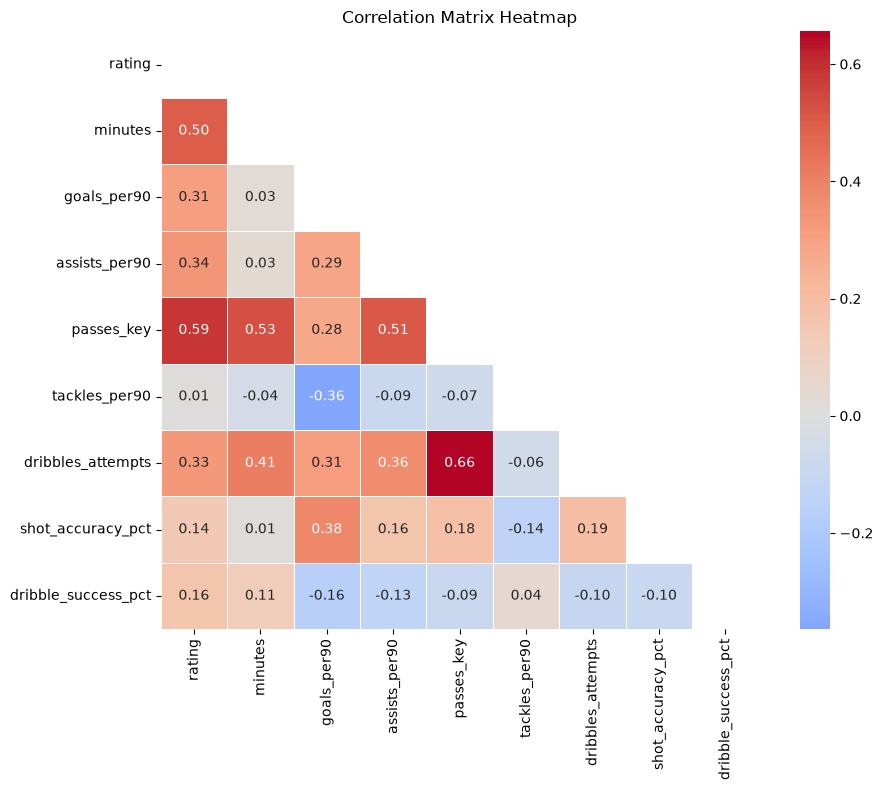

In [23]:
cols = ['rating', 'minutes', 'goals_per90', 'assists_per90', 
        'passes_key', 'tackles_per90', 'dribbles_attempts', 
        'shot_accuracy_pct', 'dribble_success_pct']

corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()